<a href="https://colab.research.google.com/github/PreciousAkpokighe/AI-ML-Training-course-professional-programme-with-Imperial-College-London/blob/main/Self_study_try_it_activity_14_1_Selecting_hyperplanes_for_two_dimensional_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 14.1: Selecting hyperplanes for two-dimensional data

## Assignment overview:

In this assignment, you will work with two different sets of data points — one exhibiting a linear pattern and the other a non-linear pattern. Your task is to determine which type of kernel performs best for each data set and provide a rationale for your selection.



In [1]:
# Import the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Use the following to plot SVMs.
from mlxtend.plotting import plot_decision_regions # On terminal, install: pip install mlxtend

#### Task 1: SVM-based classifier on a simple data set
Load the two-dimensional data `Case1linear/X.npy` that has 20 rows and two columns, and the corresponding target `Case1linear/y.npy.`

In [3]:
n = 20 # n points in each group
# number used for colour array construction (assumes balanced classes)
X = np.load('X.npy')
y = np.load('y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

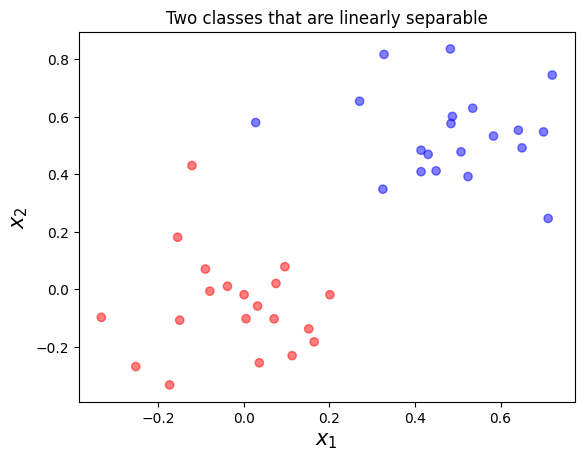

In [4]:
color = np.concatenate((np.repeat("red", n), np.repeat("blue",n)), axis=0) #y is split half half
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("Two classes that are linearly separable")
plt.show()

**Train an SVM classifier with a linear kernel.**

In [5]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set.**

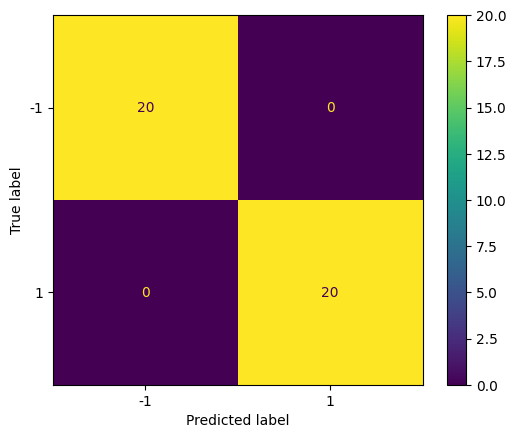

In [6]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

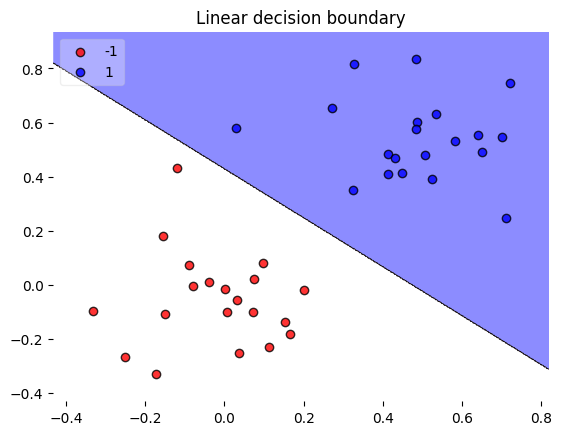

In [7]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

## Question:
Relate the visualisation of the decision boundary with the performance observed in the confusion matrix.

## Answer:
The data is linearly separable, as shown in the visualisation, so the confusion matrix indicates perfect classification.

#### Task 2: SVM-based classifier on nested data
Load the two-dimensional data `Case1rings/X.npy` that has 150 rows and two columns, and the corresponding target `Case1rings/y.np`.

In [9]:
X = np.load('X.npy')
y = np.load('y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

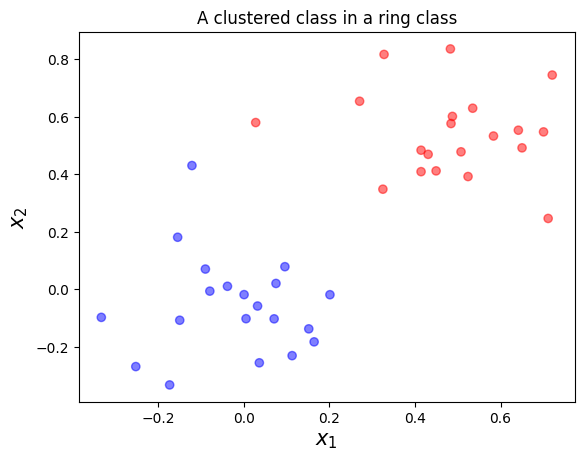

In [11]:
unique_labels = np.unique(y)
if len(unique_labels) == 2:
    color_map = {unique_labels[0]: "blue", unique_labels[1]: "red"}
    color = np.array([color_map[label] for label in y])
else:
    # Fallback or error handling for more than two classes
    # For this problem, we expect 2 classes.
    color = np.array(['blue' if label == -1 else 'red' for label in y]) # Assuming -1 and 1 as labels
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("A clustered class in a ring class")
plt.show()

**Train an SVM classifier with a linear kernel.**

In [12]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set.**

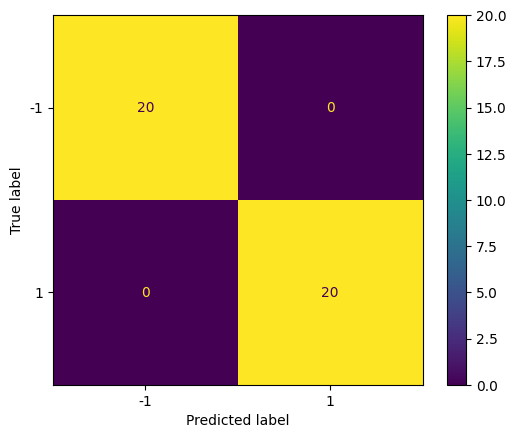

In [13]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

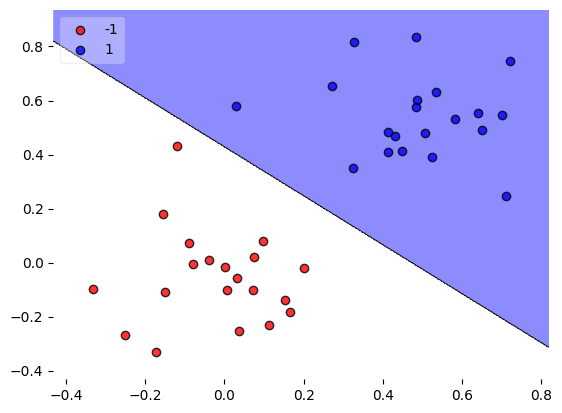

In [14]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Train an SVM classifier with a radial kernel.**

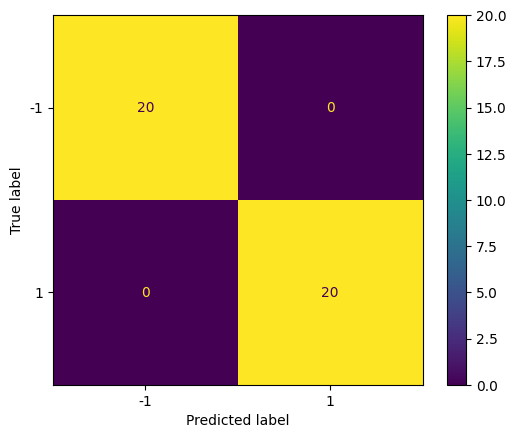

In [15]:
clf = svm.SVC(kernel = 'rbf')
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

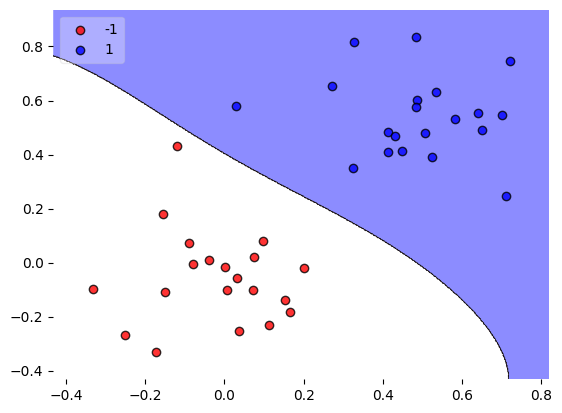

In [16]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Try polynomial kernel with degree 2.**

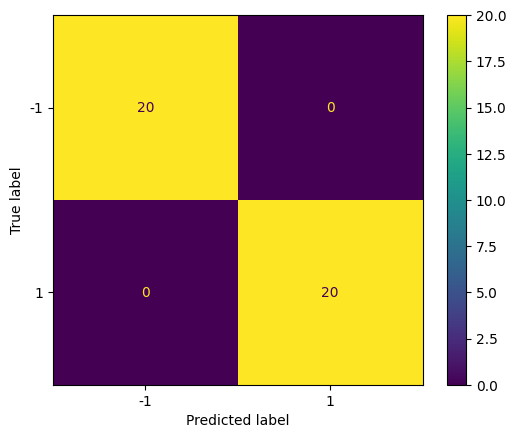

In [17]:
clf = svm.SVC(kernel = 'poly', degree = 2)
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

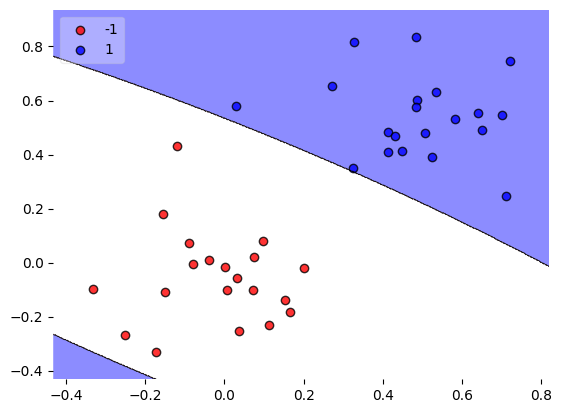

In [18]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

## Question:
Compare the classifiers obtained in this case and discuss why some are better than others.

## Answer:

RBF and polynomial kernels succeed because they model non-linear decision boundaries, whereas linear SVM fails on non-linearly separable data.